<a href="https://colab.research.google.com/github/nisadar-code/myCode/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# Neural Network on Iris Dataset (PyTorch)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# For reproducibility
torch.manual_seed(42)

# 1. Load the Iris dataset
# -------------------------
iris = load_iris()
X = iris.data        # shape: (150, 4)  -> 4 features
y = iris.target      # shape: (150,)    -> labels: 0, 1, 2

print("Feature matrix shape:", X.shape)
print("Labels shape        :", y.shape)
print("Classes             :", iris.target_names)

Feature matrix shape: (150, 4)
Labels shape        : (150,)
Classes             : ['setosa' 'versicolor' 'virginica']


In [3]:
# 2. Train/Test Split
# --------------------
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# 3. Standardize features
# ------------------------
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_test_np = scaler.transform(X_test_np)

In [5]:
# 4. Convert NumPy arrays to PyTorch tensors
# ------------------------------------------
X_train = torch.tensor(X_train_np, dtype=torch.float32)   # (n_train, 4)
X_test = torch.tensor(X_test_np, dtype=torch.float32)     # (n_test, 4)

y_train = torch.tensor(y_train_np, dtype=torch.long)      # (n_train,)
y_test = torch.tensor(y_test_np, dtype=torch.long)        # (n_test,)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 120
Test size : 30


In [6]:
# 5. Define a smaller neural network with dropout
# -----------------------------------------------
class IrisNet(nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        # Smaller hidden layer: 4 -> 4 -> 3 (was 4 -> 8 -> 3)
        self.hidden = nn.Linear(4, 4)
        self.dropout = nn.Dropout(p=0.2)  # randomly drops 20% of hidden units
        self.output = nn.Linear(4, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch_size, 4)
        z1 = self.hidden(x)
        a1 = self.relu(z1)
        a1 = self.dropout(a1)         # apply dropout only during training
        logits = self.output(a1)      # (batch_size, 3), raw class scores
        return logits

model = IrisNet()

In [7]:
# 6. Loss function and optimizer
# -------------------------------
criterion = nn.CrossEntropyLoss()

# Lower learning rate and a bit of weight decay (L2 regularization) to avoid overfitting
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [8]:
# 7. Training loop
# --------------------------------
epochs = 200

train_losses = []
test_losses = []

for epoch in range(1, epochs + 1):
    model.train()  # training mode (enables dropout)

    # ---- Forward pass on training data ----
    logits_train = model(X_train)
    loss = criterion(logits_train, y_train)

    # ---- Backward + update ----
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Store training loss
    train_losses.append(loss.item())

    # ---- Evaluate on test data each epoch ----
    model.eval()  # evaluation mode (disables dropout)
    with torch.no_grad():
        logits_test = model(X_test)
        test_loss = criterion(logits_test, y_test)
        test_losses.append(test_loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Train Loss = {loss.item():.4f} | Test Loss = {test_loss.item():.4f}")

Epoch  20 | Train Loss = 1.0075 | Test Loss = 1.0241
Epoch  40 | Train Loss = 0.9369 | Test Loss = 0.9738
Epoch  60 | Train Loss = 0.9013 | Test Loss = 0.9283
Epoch  80 | Train Loss = 0.8742 | Test Loss = 0.8850
Epoch 100 | Train Loss = 0.8277 | Test Loss = 0.8426
Epoch 120 | Train Loss = 0.8170 | Test Loss = 0.8019
Epoch 140 | Train Loss = 0.7748 | Test Loss = 0.7625
Epoch 160 | Train Loss = 0.7421 | Test Loss = 0.7242
Epoch 180 | Train Loss = 0.6787 | Test Loss = 0.6886
Epoch 200 | Train Loss = 0.6693 | Test Loss = 0.6550


In [9]:
# 8. Final evaluation on test set
# --------------------------------
model.eval()
with torch.no_grad():
    logits_test = model(X_test)
    preds_test = torch.argmax(logits_test, dim=1)

correct = (preds_test == y_test).sum().item()
total = y_test.shape[0]
accuracy = correct / total

print("\n=== Test Set Evaluation ===")
print(f"Accuracy on test set: {accuracy * 100:.2f}%")


=== Test Set Evaluation ===
Accuracy on test set: 70.00%


In [10]:
# 9. Show a few predictions
# --------------------------
print("\nSome test examples (first 10):")
for i in range(min(10, total)):
    features = X_test[i].numpy()
    true_label = y_test[i].item()
    pred_label = preds_test[i].item()

    print(f"Sample {i+1:2d}: features={features} | true={true_label} | pred={pred_label} "
          f"({iris.target_names[pred_label]})")


Some test examples (first 10):
Sample  1: features=[-1.7215677  -0.10821272 -1.4025038  -1.3232756 ] | true=0 | pred=0 (setosa)
Sample  2: features=[ 0.30848902 -0.10821272  0.6416313   0.7834318 ] | true=2 | pred=2 (virginica)
Sample  3: features=[-1.1244923 -1.4515431 -0.2668732 -0.2699219] | true=1 | pred=0 (setosa)
Sample  4: features=[-1.0050771 -1.6754315 -0.2668732 -0.2699219] | true=1 | pred=0 (setosa)
Sample  5: features=[-1.7215677   0.33956406 -1.4025038  -1.3232756 ] | true=0 | pred=0 (setosa)
Sample  6: features=[0.54731923 0.5634524  0.52806824 0.5200934 ] | true=1 | pred=2 (virginica)
Sample  7: features=[-1.4827375  1.2351177 -1.5728484 -1.3232756] | true=0 | pred=0 (setosa)
Sample  8: features=[-0.5274167  0.7873408 -1.1753777 -1.3232756] | true=0 | pred=0 (setosa)
Sample  9: features=[ 0.78614944 -0.10821272  0.8119759   1.0467702 ] | true=2 | pred=2 (virginica)
Sample 10: features=[-0.5274167  -0.10821272  0.41450518  0.3884242 ] | true=1 | pred=0 (setosa)


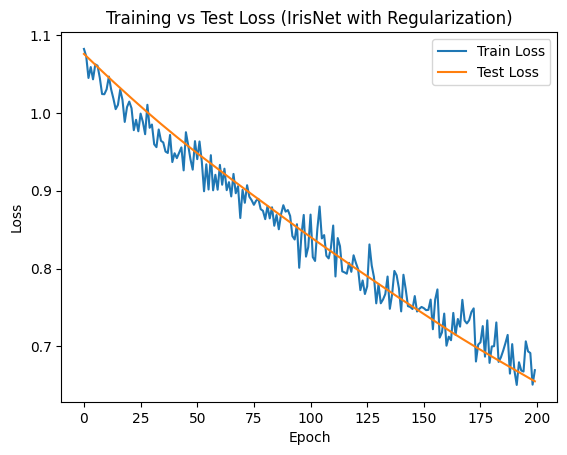

In [11]:
# 10. (Optional) Plot loss curves
# -------------------------------
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss (IrisNet with Regularization)")
plt.legend()
plt.show()
